GPU runtime verification

In [ ]:
!nvidia-smi
!python -c "import torch; print('GPU available:', torch.cuda.is_available())"

Fri Mar  6 16:37:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Clone the GNN-IDS source code


In [ ]:
!git clone https://github.com/zhenlus/GNN-IDS.git
%cd GNN-IDS

Cloning into 'GNN-IDS'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 40 (delta 13), reused 31 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 19.77 MiB | 14.66 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/GNN-IDS




```
Confirm project structure
```



In [ ]:
%cd /content/GNN-IDS
!ls

/content/GNN-IDS
datasets  install.sh  LICENSE  mulval_attack_graph  README.MD  src


Install required libraries for GNN training

In [ ]:
!pip install torch-geometric==2.3.1
!pip install scikit-learn
!pip install matplotlib
!pip install pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.6/661.6 kB 40.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for torch-geometric: filename=torch_geometric-2.3.1-py3-none-any.whl size=910495 sha256=915cbfb96f64b22838991061dfd15cc1697ad7f9da0f2189934e99ecaa984963
  Stored in directory: /root/.cache/pip/wheels/1f/e0/ac/5718630b1a754d4da59f1fdb5593efb53b2d20c535888ac578
Successfully built torch-geometric


Final environment validation

In [ ]:
!python -c "import numpy as np; import torch; import torch_geometric; print('numpy', np.__version__); print('torch', torch.__version__); print('gpu', torch.cuda.is_available()); print('pyg ok')"

numpy 2.0.2
torch 2.10.0+cu128
gpu True
pyg ok


Baseline reproduction using Dataset 1, synthetic data

In [ ]:
%cd /content/GNN-IDS/src
!ls

/content/GNN-IDS/src
ag_utils.py		models.py	synthetic_data.py
gnn_ids_dataset1.ipynb	model_utils.py
gnn_ids_dataset2.ipynb	public_data.py


Running Dataset 1

Import Required Libraries and Project Modules

In [ ]:
import os
import time
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

from ag_utils import Corpus, parse_ag_file, parse_node_properties
from synthetic_data import gene_dataset
from models import NN, GCN, GAT, GCN_EW
from model_utils import train, predict_prob, evaluate_performance

print("imports ok")

imports ok


Load and Parse the Attack Graph

In [ ]:
attack_graph_path = '../mulval_attack_graph/AttackGraph.dot'
nodes, edges, node_properties = parse_ag_file(attack_graph_path)
node_dict = parse_node_properties(nodes, node_properties)

corpus = Corpus(node_dict)
num_tokens = corpus.get_num_tokens()
node_features = corpus.get_node_features()
node_types = corpus.get_node_types()
vocab_size = len(corpus.dictionary)

print('vocab_size:', vocab_size)
print('num_tokens:', num_tokens)
print('node_features shape:', node_features.shape)

vocab_size: 57
num_tokens: 118
node_features shape: torch.Size([26, 57])


Analyze Graph Structure and Action Nodes

In [ ]:
# statistics of the encoded attack graph
num_nodes = len(nodes)
print('num_nodes: ', num_nodes)

num_node_features = node_features.shape[1]
print('num_node_features: ', num_node_features)

num_edges = len(edges)
print('num_edges: ', num_edges)

action_nodes = corpus.get_action_nodes()
action_node_idx = list(action_nodes.keys())
num_action_nodes = len(action_node_idx)
print('action_node_idx: ', action_node_idx)
print('num_action_nodes: ', num_action_nodes)

# var 'action_mask' is for representing the attack scenarios in attack graph (i.e., the privilege nodes)
action_mask = action_node_idx

num_nodes:  26
num_node_features:  57
num_edges:  26
action_node_idx:  [0, 2, 4, 7, 9, 12, 14]
num_action_nodes:  7


Construct Graph Edge Index

In [ ]:
# adj matrix and edge index
adj_matrix = torch.zeros(len(nodes), len(nodes))

for edge in edges:
    source_node, target_node = edge
    source_index = nodes.index(source_node)
    target_index = nodes.index(target_node)
    adj_matrix[source_index][target_index] = 1

edge_index = adj_matrix.nonzero().t().contiguous()

assert edge_index.shape[0]==2

Prepare Load Synthetic Dataset 1

In [ ]:
# prepare Dataset 1
num_benign = 1500
num_malic = 500
rt_meas_dim = 78
sample_method = 'synthetic'

X, Y = gene_dataset(num_benign, num_malic, num_nodes, action_nodes, rt_meas_dim)
num_samples = X.shape[0]

# rescale the data with min-max scaler
scaler = MinMaxScaler(feature_range=(0, 1))
X = scaler.fit_transform(X.view(-1, rt_meas_dim))
X = torch.from_numpy(X).float().view(num_samples, num_nodes, rt_meas_dim)

# associate node features in attack graph with real-time measurements
node_feat_ts = torch.stack([node_features for _ in range(len(X))], dim=0)
X = torch.cat((node_feat_ts, X), dim=2)

# split the data into training, validation and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.25, random_state=42, stratify=Y_train)
print(X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape)

torch.Size([3000, 26, 135]) torch.Size([3000, 7]) torch.Size([1000, 26, 135]) torch.Size([1000, 7]) torch.Size([1000, 26, 135]) torch.Size([1000, 7])


In [ ]:
# load Dataset 1 used in the paper
data_path = '../datasets/synt/'
X_train = torch.load(data_path+'X_train-{}.pth'.format(sample_method))
X_val   = torch.load(data_path+'X_val-{}.pth'.format(sample_method))
X_test  = torch.load(data_path+'X_test-{}.pth'.format(sample_method))
Y_train = torch.load(data_path+'Y_train-{}.pth'.format(sample_method))
Y_val   = torch.load(data_path+'Y_val-{}.pth'.format(sample_method))
Y_test  = torch.load(data_path+'Y_test-{}.pth'.format(sample_method))
print(X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape)

torch.Size([3000, 26, 135]) torch.Size([3000, 7]) torch.Size([1000, 26, 135]) torch.Size([1000, 7]) torch.Size([1000, 26, 135]) torch.Size([1000, 7])


Train Model

In [ ]:
# hyperparameters for training
in_dim = X_train.shape[-1]
hidden_dim = 20
out_dim = 1
lr = 0.001
device = 'cpu'
# model initialization
models = {}
model_NN = NN(rt_meas_dim, hidden_dim, out_dim)
model_GCN = GCN(in_dim, hidden_dim, out_dim)
model_GCN_EW = GCN_EW(in_dim, hidden_dim, out_dim, edge_index)
model_GAT = GAT(hidden_channels=hidden_dim, heads=4, in_dim=in_dim, out_dim=out_dim)

models['NN'] = model_NN
models['GCN'] = model_GCN
models['GCN-EW'] = model_GCN_EW
models['GAT'] = model_GAT

for name, model in models.items():
    model.name = name
    model.action_mask = action_mask
    num_epochs = 2 # early stop when overfitting observed

    print(f'{model.name} start training...')
    time_start = time.time()
    print('model: ', model)
    train(model, lr, num_epochs, X_train, Y_train, X_val, Y_val, edge_index, rt_meas_dim, device)
    time_end = time.time()
    print('time cost: ', time_end - time_start)
    print(f'{model.name} training finished!')

    print(f'{model.name} accuracy on training set: {model.stat["acc_train"][-1]}')
    print(f'{model.name} accuracy on validation set: {model.stat["acc_val"][-1]}')

NN start training...
model:  NN(
  (lin1): Linear(in_features=78, out_features=20, bias=True)
  (lin2): Linear(in_features=20, out_features=20, bias=True)
  (out_layer): Linear(in_features=20, out_features=1, bias=True)
)
time cost:  5.704551696777344
NN training finished!
NN accuracy on training set: 0.7447142857142857
NN accuracy on validation set: 0.7424285714285714
GCN start training...
model:  GCN(
  (conv1): GCNConv(135, 20)
  (conv2): GCNConv(20, 20)
  (classifier): Linear(in_features=20, out_features=1, bias=True)
)
time cost:  0.8717238903045654
GCN training finished!
GCN accuracy on training set: 0.9027142857142857
GCN accuracy on validation set: 0.9027142857142857
GCN-EW start training...
model:  GCN_EW(
  (conv1): GCNConv(135, 20)
  (conv2): GCNConv(20, 20)
  (classifier): Linear(in_features=20, out_features=1, bias=True)
)
time cost:  1.0171895027160645
GCN-EW training finished!
GCN-EW accuracy on training set: 0.8911428571428571
GCN-EW accuracy on validation set: 0.891
GA

Plot the roc curve

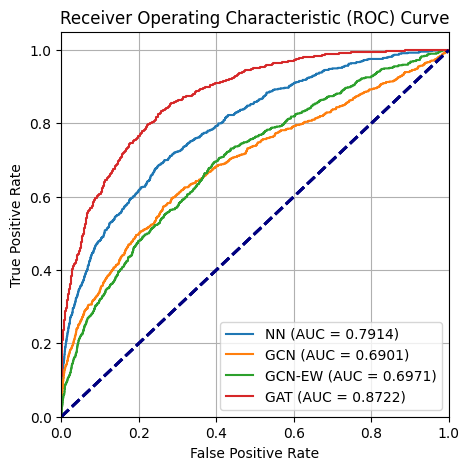

In [ ]:
# plot the roc curve
from sklearn.metrics import roc_curve, auc
fig, ax = plt.subplots(figsize=(5, 5))
for name, model in models.items():
    prob = predict_prob(model, X_test, edge_index)
    y_probs = prob.view(-1, 2)

    fpr, tpr, thresholds = roc_curve(Y_test.view(-1), y_probs[:, 1])
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, label='{} (AUC = {:.4f})'.format(model.name, roc_auc))
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_title('Receiver Operating Characteristic (ROC) Curve')
    ax.legend(loc="lower right")
ax.grid()
plt.show()

Performance evaluation

In [ ]:
# performance evaluation
metrics = evaluate_performance(models, X_test, Y_test, edge_index, device)
df = pd.DataFrame(metrics)
print(df)

    model    TN    FP   FN   TP precision  recall      f1     auc     fpr  \
0      NN  4688  1612  219  481    0.5926  0.7156  0.5905  0.7914  0.2559   
1     GCN  6292     8  673   27    0.8374  0.5187  0.5111  0.6901  0.0013   
2  GCN-EW  6125   175  601   99    0.6360  0.5568  0.5719  0.6971  0.0278   
3     GAT  4382  1918   95  605    0.6093  0.7799  0.5943  0.8722  0.3044   

      fnr loss_train loss_val acc_train acc_val accuracy  
0  0.3129     0.9820   0.9970    0.7447  0.7424   0.7384  
1  0.9614     1.2363   1.2379    0.9027  0.9027   0.9027  
2  0.8586     1.2281   1.2307    0.8911  0.8910   0.8891  
3  0.1357     0.7826   0.7981    0.7117  0.7121   0.7124  


Plot the TP, FP, TN, FN

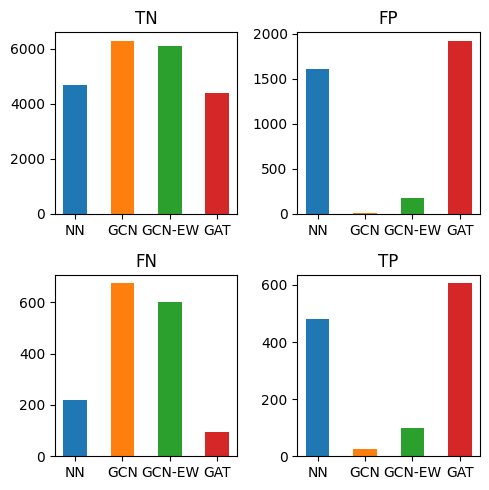

In [ ]:
# plot the TP, FP, TN, FN
fig, axs = plt.subplots(2, 2, figsize=(5, 5))
axs = axs.ravel()

bar_width = 0.5
labels = ['TN', 'FP', 'FN', 'TP']

for i, label in enumerate(labels):
    for j, name in enumerate(models):
        rects = axs[i].bar(j, metrics[j][label], width=bar_width, label=name)
    axs[i].set_xticks(np.arange(len(models)))
    axs[i].set_xticklabels(models.keys())
    for tick in axs[i].xaxis.get_major_ticks():
        tick.label1.set_fontsize(10)
    axs[i].set_title(label)

handles, labels = axs[0].get_legend_handles_labels()

plt.tight_layout()
plt.show()

Robustness evaluation

In [ ]:
# robustness evaluation
for i in range(Y_test.shape[0]):
    for j in range(len(action_mask)):
        if Y_test[i, j] == 1:
            for k in range(rt_meas_dim):
                if True:
                    X_test[i, action_mask[j],-rt_meas_dim+k] -= torch.normal(mean=0.0, std=0.05, size=(1,)).item()

metrics = evaluate_performance(models, X_test, Y_test, edge_index, device)
df = pd.DataFrame(metrics)
print(df)

    model    TN    FP   FN   TP precision  recall      f1     auc     fpr  \
0      NN  4688  1612  220  480    0.5923  0.7149  0.5902  0.7857  0.2559   
1     GCN  6293     7  667   33    0.8646  0.5230  0.5192  0.6871  0.0011   
2  GCN-EW  6121   179  592  108    0.6441  0.5629  0.5798  0.6932  0.0284   
3     GAT  4379  1921  102  598    0.6073  0.7747  0.5919  0.8676  0.3049   

      fnr loss_train loss_val acc_train acc_val accuracy  
0  0.3143     0.9820   0.9970    0.7447  0.7424   0.7383  
1  0.9529     1.2363   1.2379    0.9027  0.9027   0.9037  
2  0.8457     1.2281   1.2307    0.8911  0.8910   0.8899  
3  0.1457     0.7826   0.7981    0.7117  0.7121   0.7110  


Individual case analysis

In [ ]:
from torch_geometric.data import Data
from torch_geometric.explain import GNNExplainer, Explainer

# individual case analysis
found = False
while not found:
    indi_case_id = torch.randint(0, X_test.shape[0], (1,)).item()
    y_true = Y_test[indi_case_id]
    if y_true.sum() != 0:
        found = True
        print('indi_case_id: ', indi_case_id)

indi_case_x = X_test[indi_case_id]
indi_case_x = indi_case_x.unsqueeze(0)

indi_case_id:  714


Explainability visualization

model prob_ts: 
 tensor([0.4529, 0.4566, 0.4918, 0.4584, 0.4826, 0.4821, 0.4743],
       grad_fn=<IndexBackward0>)
y_true:  tensor([0., 0., 1., 0., 0., 0., 0.])


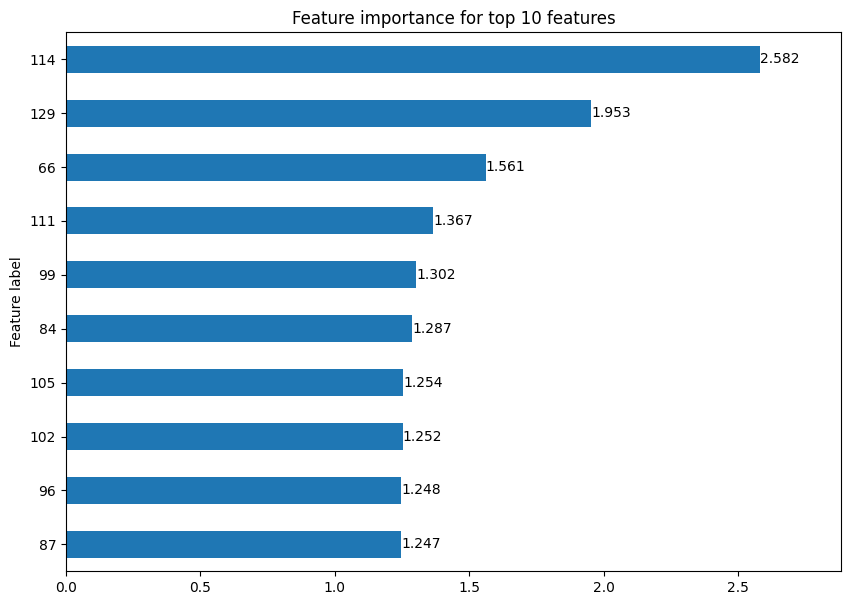

In [ ]:
# Explainability visualization
model_to_explain = model_GCN_EW
model_to_explain.eval()
if model.name in ['GAT']:
    indi_case_x = indi_case_x.view(-1, in_dim)
prob_ts = torch.sigmoid(model_to_explain(indi_case_x, edge_index))[action_mask]
print('model prob_ts: \n', prob_ts)
print('y_true: ', y_true)

data = Data(x=X_test[indi_case_id], edge_index=edge_index)

explainer = Explainer(
    model=model_to_explain,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='binary_classification',
        task_level='node',
        return_type='raw',
    ),
)

compromised_node = action_node_idx[np.where(y_true==1)[0].item()]
explanation = explainer(data.x, data.edge_index, index=compromised_node)

explanation.visualize_feature_importance(top_k=10)
explanation.visualize_graph()

store Dataset 1 model

In [ ]:
model_dataset1 = model
X_test_dataset1 = X_test
Y_test_dataset1 = Y_test
print("Dataset 1 saved")

Dataset 1 saved


Running Dataset 2

Import Required Libraries and Project Modules

In [ ]:
import os
import time
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

from ag_utils import Corpus
from ag_utils import parse_ag_file
from ag_utils import parse_node_properties

from public_data import gene_dataset

from models import NN, GCN, GCN_EW, GAT
from model_utils import train, predict_prob, evaluate_performance

load and Parse attack graph file generated by MulVAL tool

In [ ]:
# parse attack graph file generated by MulVAL tool
attack_graph_path = '../mulval_attack_graph/AttackGraph.dot'
nodes, edges, node_properties = parse_ag_file(attack_graph_path)
node_dict = parse_node_properties(nodes, node_properties)

# save node label into corpus object
corpus = Corpus(node_dict)
num_tokens = corpus.get_num_tokens()
node_features = corpus.get_node_features()
node_types = corpus.get_node_types()
vocab_size = len(corpus.dictionary)
print('vocab_size: ', vocab_size)
print('num_tokens: ', num_tokens)
print('node_features shape: ', node_features.shape)

vocab_size:  57
num_tokens:  118
node_features shape:  torch.Size([26, 57])


Analyze Graph Structure and Action Nodes

In [ ]:
# statistics of the encoded attack graph
num_nodes = len(nodes)
print('num_nodes: ', num_nodes)

num_node_features = node_features.shape[1]
print('num_node_features: ', num_node_features)

num_edges = len(edges)
print('num_edges: ', num_edges)

action_nodes = corpus.get_action_nodes()
action_node_idx = list(action_nodes.keys())
num_action_nodes = len(action_node_idx)
print('action_node_idx: ', action_node_idx)
print('num_action_nodes: ', num_action_nodes)

# var 'action_mask' is used to represent the attack scenarios in attack graph (i.e., the privilege nodes)
action_mask = action_node_idx

num_nodes:  26
num_node_features:  57
num_edges:  26
action_node_idx:  [0, 2, 4, 7, 9, 12, 14]
num_action_nodes:  7


Construct Graph Edge Index

In [ ]:
# adj matrix and edge index
adj_matrix = torch.zeros(len(nodes), len(nodes))

for edge in edges:
    source_node, target_node = edge
    source_index = nodes.index(source_node)
    target_index = nodes.index(target_node)
    adj_matrix[source_index][target_index] = 1

edge_index = adj_matrix.nonzero().t().contiguous()

assert edge_index.shape[0]==2

Prepare Load public Dataset 2


In [ ]:
# prepare Dataset 2
num_benign = 1500
num_malic = 500
sample_method = 'public'

X, Y= gene_dataset(action_node_idx, num_nodes, num_benign, num_malic)
rt_meas_dim = X.shape[2]

# associate node features in attack graph with real-time measurements
node_feat_ts = torch.stack([node_features for _ in range(len(X))], dim=0)
X = torch.cat((node_feat_ts, X), dim=2)

num_samples = X.shape[0]
print('num_samples: ', num_samples)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.25, random_state=42, stratify=Y_train)
print(X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape)

num_samples:  5000
torch.Size([3000, 26, 135]) torch.Size([3000, 7]) torch.Size([1000, 26, 135]) torch.Size([1000, 7]) torch.Size([1000, 26, 135]) torch.Size([1000, 7])


load Dataset 2

In [ ]:
# load Dataset 2 used in the paper
data_path = '../datasets/public/'
X_train = torch.load(data_path+'X_train-{}.pth'.format(sample_method))
X_val   = torch.load(data_path+'X_val-{}.pth'.format(sample_method))
X_test  = torch.load(data_path+'X_test-{}.pth'.format(sample_method))
Y_train = torch.load(data_path+'Y_train-{}.pth'.format(sample_method))
Y_val   = torch.load(data_path+'Y_val-{}.pth'.format(sample_method))
Y_test  = torch.load(data_path+'Y_test-{}.pth'.format(sample_method))
print(X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape)

torch.Size([3000, 26, 135]) torch.Size([3000, 7]) torch.Size([1000, 26, 135]) torch.Size([1000, 7]) torch.Size([1000, 26, 135]) torch.Size([1000, 7])


Train Model

In [ ]:

# hyperparameters for training
in_dim = X_train.shape[-1]
hidden_dim = 20
out_dim = 1
lr = 0.001
device = 'cpu'
# model initialization
models = {}
model_NN = NN(78, hidden_dim, out_dim)
model_GCN = GCN(in_dim, hidden_dim, out_dim)
model_GCN_EW = GCN_EW(in_dim, hidden_dim, out_dim, edge_index)
model_GAT = GAT(hidden_channels=hidden_dim, heads=4, in_dim=in_dim, out_dim=out_dim)

models['NN'] = model_NN
models['GCN'] = model_GCN
models['GCN-EW'] = model_GCN_EW
models['GAT'] = model_GAT

for name, model in models.items():
    model.name = name
    model.action_mask = action_mask

    num_epochs = 2 # early stop when overfitting observed
    print(f'{model.name} start training...')
    time_start = time.time()
    print('model: ', model)
    train(model, lr, num_epochs, X_train, Y_train, X_val, Y_val, edge_index, rt_meas_dim, device)
    time_end = time.time()
    print('time cost: ', time_end - time_start)
    print(f'{model.name} training finished!')

    print(f'{model.name} accuracy on training set: {model.stat["acc_train"][-1]}')
    print(f'{model.name} accuracy on validation set: {model.stat["acc_val"][-1]}')

NN start training...
model:  NN(
  (lin1): Linear(in_features=78, out_features=20, bias=True)
  (lin2): Linear(in_features=20, out_features=20, bias=True)
  (out_layer): Linear(in_features=20, out_features=1, bias=True)
)
time cost:  0.33938169479370117
NN training finished!
NN accuracy on training set: 0.7592857142857142
NN accuracy on validation set: 0.7624285714285715
GCN start training...
model:  GCN(
  (conv1): GCNConv(135, 20)
  (conv2): GCNConv(20, 20)
  (classifier): Linear(in_features=20, out_features=1, bias=True)
)
time cost:  0.795137882232666
GCN training finished!
GCN accuracy on training set: 0.7402380952380953
GCN accuracy on validation set: 0.7441428571428571
GCN-EW start training...
model:  GCN_EW(
  (conv1): GCNConv(135, 20)
  (conv2): GCNConv(20, 20)
  (classifier): Linear(in_features=20, out_features=1, bias=True)
)
time cost:  0.9591708183288574
GCN-EW training finished!
GCN-EW accuracy on training set: 0.7616666666666667
GCN-EW accuracy on validation set: 0.76057

Performance evaluation

In [ ]:
metrics = evaluate_performance(models, X_test, Y_test, edge_index, device)
df = pd.DataFrame(metrics)
print(df)

    model    TN    FP   FN   TP precision  recall      f1     auc     fpr  \
0      NN  4669  1631   69  631    0.6322  0.8213  0.6360  0.9205  0.2589   
1     GCN  4632  1668  142  558    0.6105  0.7662  0.6090  0.8468  0.2648   
2  GCN-EW  4773  1527  123  577    0.6246  0.7910  0.6321  0.8789  0.2424   
3     GAT  5598   702   18  682    0.7448  0.9314  0.7970  0.9766  0.1114   

      fnr loss_train loss_val acc_train acc_val accuracy  
0  0.0986     0.7045   0.6890    0.7593  0.7624   0.7571  
1  0.2029     1.0549   1.0550    0.7402  0.7441   0.7414  
2  0.1757     0.9874   0.9875    0.7617  0.7606   0.7643  
3  0.0257     0.3519   0.3459    0.8956  0.8989   0.8971  


Plot the roc curve

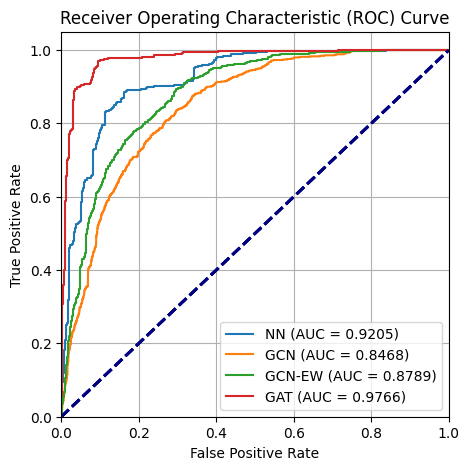

In [ ]:
#plot the roc curve
from sklearn.metrics import roc_curve, auc
fig, ax = plt.subplots(figsize=(5, 5))
for name, model in models.items():
    prob = predict_prob(model, X_test, edge_index)
    y_probs = prob.view(-1, 2)

    fpr, tpr, thresholds = roc_curve(Y_test.view(-1), y_probs[:, 1])
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, label='{} (AUC = {:.4f})'.format(model.name, roc_auc))
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_title('Receiver Operating Characteristic (ROC) Curve')
    ax.legend(loc="lower right")
ax.grid()
plt.show()

Plot the TP, FP, TN, FN for each model

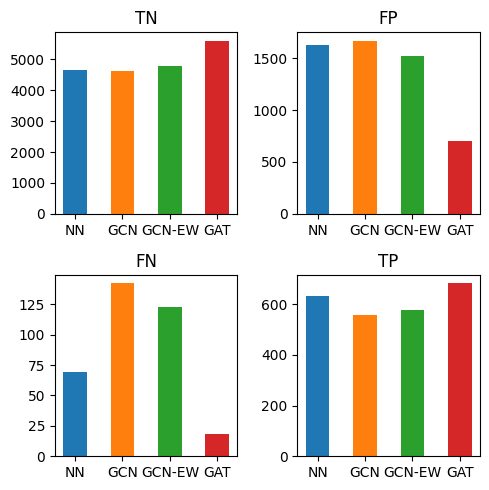

In [ ]:
# plot the TP, FP, TN, FN for each model
fig, axs = plt.subplots(2, 2, figsize=(5, 5))
axs = axs.ravel()

bar_width = 0.5
labels = ['TN', 'FP', 'FN', 'TP']

for i, label in enumerate(labels):
    for j, name in enumerate(models):
        rects = axs[i].bar(j, metrics[j][label], width=bar_width, label=name)
    axs[i].set_xticks(np.arange(len(models)))
    axs[i].set_xticklabels(models.keys())
    for tick in axs[i].xaxis.get_major_ticks():
        tick.label1.set_fontsize(10)
    axs[i].set_title(label)

handles, labels = axs[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.2, 1))

plt.tight_layout()
plt.show()

Robustness evaluation

In [ ]:
# robustness evaluation
for i in range(Y_test.shape[0]):
    for j in range(len(action_mask)):
        if Y_test[i, j] == 1:
            for k in range(rt_meas_dim):
                X_test[i, action_mask[j],-rt_meas_dim+k] += torch.normal(mean=0, std=0.01, size=(1,)).item()

metrics = evaluate_performance(models, X_test, Y_test, edge_index, device)
df = pd.DataFrame(metrics)
print(df)

    model    TN    FP   FN   TP precision  recall      f1     auc     fpr  \
0      NN  4669  1631   70  630    0.6319  0.8206  0.6357  0.9191  0.2589   
1     GCN  4629  1671  142  558    0.6103  0.7660  0.6086  0.8466  0.2652   
2  GCN-EW  4771  1529  123  577    0.6244  0.7908  0.6318  0.8786  0.2427   
3     GAT  5598   702   20  680    0.7442  0.9300  0.7963  0.9763  0.1114   

      fnr loss_train loss_val acc_train acc_val accuracy  
0  0.1000     0.7045   0.6890    0.7593  0.7624   0.7570  
1  0.2029     1.0549   1.0550    0.7402  0.7441   0.7410  
2  0.1757     0.9874   0.9875    0.7617  0.7606   0.7640  
3  0.0286     0.3519   0.3459    0.8956  0.8989   0.8969  


Individual case analysis

In [ ]:
from torch_geometric.data import Data
from torch_geometric.explain import GNNExplainer, Explainer

# individual case analysis
found = False
while not found:
    indi_case_id = torch.randint(0, X_test.shape[0], (1,)).item()
    y_true = Y_test[indi_case_id]
    if y_true[2] != 0:
        found = True
        print('indi_case_id: ', indi_case_id)
indi_case_x = X_test[indi_case_id]

indi_case_id:  714


Explainability visualization

model prob_ts: 
 tensor([0.3276, 0.2564, 0.5937, 0.3850, 0.4759, 0.3134, 0.2915],
       grad_fn=<IndexBackward0>)
y_true:  tensor([0., 0., 1., 0., 0., 0., 0.])


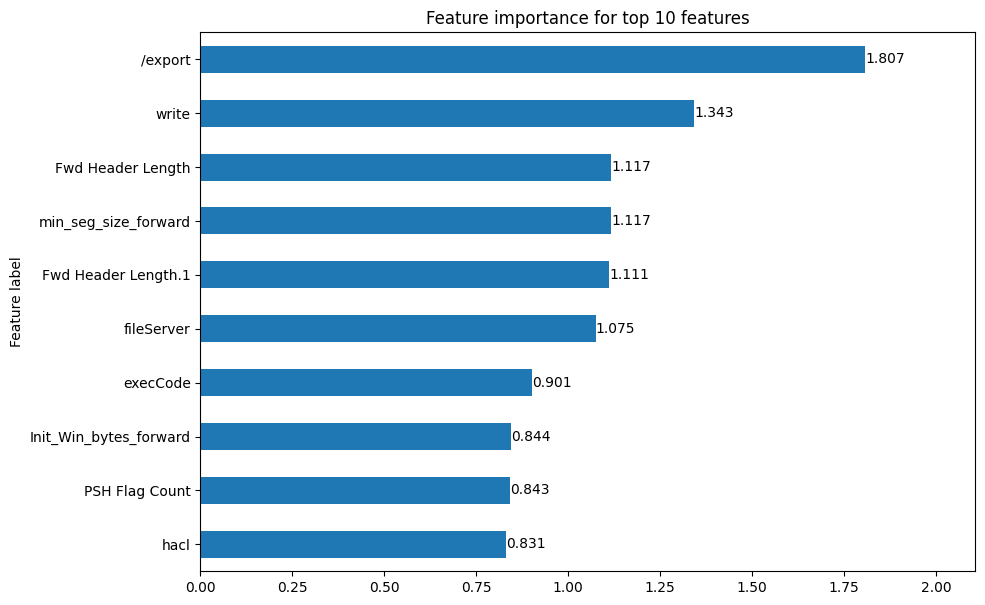

In [ ]:
# Explainability visualization

model_to_explain = model_GCN_EW
model_to_explain.eval()
if model.name in ['GAT']:
    indi_case_x = indi_case_x.view(-1, in_dim)
prob_ts = torch.sigmoid(model_to_explain(indi_case_x, edge_index))[action_mask]

print('model prob_ts: \n', prob_ts)
print('y_true: ', y_true)

data = Data(x=X_test[indi_case_id], edge_index=edge_index)

explainer = Explainer(
    model=model_to_explain,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='binary_classification',
        task_level='node',
        return_type='raw',
    ),

)

feat_labels_ag = corpus.dictionary.idx2word.values()
feat_labels_ag = list(feat_labels_ag)
feat_labels_rtm = pd.read_csv('../datasets/public/CICIDS-2017.csv').columns.tolist()[:-1]
feat_labels_rtm = [feat.strip() for feat in feat_labels_rtm]
feat_labels = feat_labels_ag + feat_labels_rtm

compromised_node = action_node_idx[np.where(y_true==1)[0].item()]
explanation = explainer(data.x, data.edge_index, index=compromised_node)

explanation.visualize_feature_importance(feat_labels=feat_labels, top_k=10)
explanation.visualize_graph()

Store Dataset 2 model

In [ ]:
model_dataset2 = model
X_test_dataset2 = X_test
Y_test_dataset2 = Y_test
print("Dataset 2 saved")

Dataset 2 saved


Confirm the 2 Datases exist

In [ ]:
print("Dataset1 model:", "model_dataset1" in globals())
print("Dataset2 model:", "model_dataset2" in globals())

Dataset1 model: True
Dataset2 model: True


Install Gradio

In [ ]:
pip install gradio

Set models to evaluation mode

In [ ]:
model_dataset1.eval()
model_dataset2.eval()

GAT(
  (conv1): GATConv(135, 20, heads=4)
  (conv2): GATConv(80, 20, heads=4)
  (classifier): Linear(in_features=80, out_features=1, bias=True)
)

Create prediction function

In [ ]:
import torch

model_dataset1.eval()
model_dataset2.eval()

def predict(dataset_choice, sample_index):

    sample_index = int(sample_index)

    if dataset_choice == "Dataset 1":
        model = model_dataset1
        X_test = X_test_dataset1
        Y_test = Y_test_dataset1
    else:
        model = model_dataset2
        X_test = X_test_dataset2
        Y_test = Y_test_dataset2

    x_sample = X_test[sample_index]

    with torch.no_grad():
        output = model(x_sample, edge_index)
        prob = torch.sigmoid(output)

    # Only check action nodes
    prob_actions = prob[action_mask]

    predicted_node_indices = (prob_actions > 0.5).nonzero(as_tuple=True)[0]

    if len(predicted_node_indices) > 0:
        attacked_node = action_mask[predicted_node_indices[0].item()]
    else:
        attacked_node = "No attack detected"

    result = f"True Label: {Y_test[sample_index].tolist()}\n\n"
    result += f"Predicted Attack Node: {attacked_node}\n\n"
    result += f"Action Node Probabilities:\n{prob_actions.squeeze().tolist()}"

    return result

Build GUI

In [ ]:
# @title  GNN-IDS  —  Gradio GUI  (redesigned)

import asyncio, sys
try:
    loop = asyncio.get_running_loop()
    loop.close()
except RuntimeError:
    pass
asyncio.set_event_loop(asyncio.new_event_loop())

import gradio as gr
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import random
import pandas as pd
import json
import pickle
import io
from torch_geometric.nn import GINConv
from huggingface_hub import hf_hub_download

# ── Architecture definitions (needed to load weights) ─────────────────────────
class GIN_Encoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_layers=3, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        dims = [in_dim] + [hidden_dim] * num_layers
        for i in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(dims[i], dims[i+1]), nn.ReLU(),
                nn.Linear(dims[i+1], dims[i+1]))
            self.convs.append(GINConv(mlp, train_eps=True))
            self.bns.append(nn.BatchNorm1d(dims[i+1]))

    def forward(self, x, edge_index):
        h = x
        for conv, bn in zip(self.convs, self.bns):
            h = F.relu(bn(conv(h, edge_index)))
            h = F.dropout(h, p=self.dropout, training=self.training)
        return h

class GIN_GRU(nn.Module):
    def __init__(self, in_dim, num_action, gin_hidden=64, gru_hidden=128,
                 gin_layers=3, gru_layers=1, dropout=0.3):
        super().__init__()
        self.name       = 'GIN_GRU'
        self.num_action = num_action
        self.gin_hidden = gin_hidden
        self.gin = GIN_Encoder(in_dim, gin_hidden, gin_layers, dropout)
        gru_input_dim = num_action * gin_hidden
        self.gru = nn.GRU(input_size=gru_input_dim, hidden_size=gru_hidden,
                          num_layers=gru_layers, batch_first=True,
                          dropout=dropout if gru_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(gru_hidden, gru_hidden // 2), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(gru_hidden // 2, num_action))

    def forward(self, X_seq, edge_index, action_mask):
        B, W, N, D = X_seq.shape
        x_flat   = X_seq.reshape(B * W, N, D)
        ei_batch = torch.cat([edge_index + i * N for i in range(B * W)], dim=1)
        h_flat   = self.gin(x_flat.reshape(B * W * N, D), ei_batch)
        h        = h_flat.reshape(B, W, N, self.gin_hidden)
        h_action = h[:, :, action_mask, :].reshape(B, W, -1)
        gru_out, _ = self.gru(h_action)
        return self.head(gru_out[:, -1, :])

# ── Load GIN-GRU from HuggingFace ─────────────────────────────────────────────
HF_REPO_ID = "shiimi/gnn-ids-models"

cfg_path = hf_hub_download(repo_id=HF_REPO_ID, filename="model_configs.json")
with open(cfg_path) as f:
    hf_configs = json.load(f)

def load_gin_gru(config_key, weight_filename):
    cfg = hf_configs[config_key]
    m   = GIN_GRU(in_dim=cfg["in_dim"], num_action=cfg["num_action"],
                  gin_hidden=cfg["gin_hidden"], gru_hidden=cfg["gru_hidden"],
                  gin_layers=cfg["gin_layers"], gru_layers=cfg["gru_layers"],
                  dropout=cfg["dropout"])
    wt_path = hf_hub_download(repo_id=HF_REPO_ID, filename=weight_filename)
    m.load_state_dict(torch.load(wt_path, map_location="cpu"))
    m.eval()
    return m, cfg

gin_gru_d2, gin_gru_d2_cfg = load_gin_gru("gin_gru_d2_w5", "gin_gru_d2_w5.pth")
gin_gru_d1, gin_gru_d1_cfg = load_gin_gru("gin_gru_d1_w5", "gin_gru_d1_w5.pth")
print("GIN-GRU models loaded from HuggingFace")

models["GIN-GRU"] = gin_gru_d2
GIN_GRU_MODELS    = {"D1": gin_gru_d1, "D2": gin_gru_d2}
GIN_GRU_WINDOW    = 5

for m in models.values():
    m.eval()

THRESHOLD     = 0.5
MODEL_OPTIONS = ["NN", "GCN", "GCN-EW", "GAT", "GIN-GRU"]

custom_store = {"model": None, "scaler": None, "label": "Custom"}

# ─────────────────────────────────────────────────────────────────────────────
# Inference helpers  (unchanged logic)
# ─────────────────────────────────────────────────────────────────────────────
def _run_inference(model, x_sample, edge_index, action_mask, threshold,
                   dataset_key="D2", custom_scaler=None):
    with torch.no_grad():
        if hasattr(model, 'name') and model.name == 'GIN_GRU':
            gin_gru = GIN_GRU_MODELS.get(dataset_key, gin_gru_d2)
            W = GIN_GRU_WINDOW
            x_seq  = x_sample.unsqueeze(0).unsqueeze(0).repeat(1, W, 1, 1)
            logits = gin_gru(x_seq, edge_index, action_mask)
            prob   = torch.sigmoid(logits).squeeze(0)
            prob_actions = prob.cpu().numpy()
        elif hasattr(model, 'name') and model.name == 'NN':
            x_inp  = x_sample[:, -rt_meas_dim:]
            output = model(x_inp)
            prob   = torch.sigmoid(output)
            prob_actions = prob[action_mask].squeeze().cpu().numpy()
        else:
            output = model(x_sample, edge_index)
            prob   = torch.sigmoid(output)
            prob_actions = prob[action_mask].squeeze().cpu().numpy()
    if prob_actions.ndim == 0:
        prob_actions = prob_actions.reshape(1)
    attacked_indices = np.where(prob_actions > threshold)[0]
    is_attack    = len(attacked_indices) > 0
    attacked_nodes = [action_mask[i] for i in attacked_indices] if is_attack else []
    return prob_actions, is_attack, attacked_nodes

def _get_true_labels(Y_test, sample_index, action_mask):
    row     = Y_test[sample_index]
    n_cols  = row.shape[0]
    safe_idx = [i for i in range(len(action_mask)) if i < n_cols]
    return row[safe_idx].cpu().numpy().astype(int)

def _node_colors(probs, true_labels, threshold):
    colors = []
    for p, t in zip(probs, true_labels):
        if   p > threshold and t == 1: colors.append("#c0392b")
        elif p > threshold and t == 0: colors.append("#e67e22")
        elif p <= threshold and t == 1: colors.append("#2980b9")
        else:                           colors.append("#27ae60")
    return colors

def _make_json_report(model_name, dataset_label, sample_index, threshold,
                      probs, true_labels, action_mask):
    nodes = []
    for i, (p, t) in enumerate(zip(probs, true_labels)):
        predicted = bool(p > threshold)
        status = ("TP" if predicted and t == 1 else
                  "FP" if predicted and t == 0 else
                  "FN" if not predicted and t == 1 else "TN")
        nodes.append({"node_id": action_mask[i], "probability": round(float(p), 6),
                      "predicted": predicted, "ground_truth": bool(t == 1), "status": status})
    tp = sum(1 for n in nodes if n["status"] == "TP")
    fp = sum(1 for n in nodes if n["status"] == "FP")
    fn = sum(1 for n in nodes if n["status"] == "FN")
    tn = sum(1 for n in nodes if n["status"] == "TN")
    prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-9)
    report = {
        "meta":       {"model": model_name, "dataset": dataset_label,
                       "snapshot": sample_index, "threshold": threshold, "source": "test_set"},
        "prediction": {"decision": "ATTACK" if any(n["predicted"] for n in nodes) else "BENIGN",
                       "ground_truth": "ATTACK" if any(n["ground_truth"] for n in nodes) else "BENIGN",
                       "correct": (any(n["predicted"] for n in nodes) ==
                                   any(n["ground_truth"] for n in nodes))},
        "metrics":    {"precision": round(prec,4), "recall": round(rec,4), "f1": round(f1,4),
                       "tp": tp, "fp": fp, "fn": fn, "tn": tn},
        "nodes":      nodes,
    }
    return json.dumps(report, indent=2)

def _bar_chart(probs, true_labels, action_mask, title, threshold):
    n      = len(probs)
    colors = _node_colors(probs, true_labels, threshold)
    BG     = "#F8F9FA"
    fig, ax = plt.subplots(figsize=(max(8, n * 1.15), 5), facecolor=BG)
    ax.set_facecolor(BG)
    fig.subplots_adjust(bottom=0.25, top=0.85, left=0.09, right=0.97)
    bars = ax.bar(np.arange(n), probs, color=colors, edgecolor="white",
                  linewidth=1.0, width=0.6, zorder=3)
    ax.axhline(threshold, color="#7f8c8d", linestyle="--", linewidth=1.4,
               label=f"Threshold ({threshold:.2f})", zorder=4)
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, min(p + 0.03, 1.10),
                f"{p:.2f}", ha="center", va="bottom", fontsize=8.5,
                fontweight="bold", color="#2c3e50")
    ax.set_xticks(np.arange(n))
    ax.set_xticklabels([f"Node {action_mask[i]}" for i in range(n)],
                       fontsize=9, rotation=30, ha="right")
    ax.set_ylim(0, 1.30)
    ax.set_ylabel("Attack Probability", fontsize=10, labelpad=8)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10, color="#1a1a2e")
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    patches = [
        mpatches.Patch(color="#c0392b", label="TP — Correct Detection"),
        mpatches.Patch(color="#e67e22", label="FP — False Alarm"),
        mpatches.Patch(color="#2980b9", label="FN — Missed Attack"),
        mpatches.Patch(color="#27ae60", label="TN — Correctly Benign"),
    ]
    ax.legend(handles=patches + [ax.get_lines()[0]],
              loc="upper center", bbox_to_anchor=(0.5, -0.20),
              ncol=3, fontsize=8.5, framealpha=0.95, edgecolor="#dddddd")
    return fig

def _comparison_chart(results, action_mask, threshold):
    n_models = len(results)
    BG = "#F8F9FA"
    fig, axs = plt.subplots(1, n_models, figsize=(5.5 * n_models, 4.5),
                             sharey=True, facecolor=BG)
    if n_models == 1:
        axs = [axs]
    fig.suptitle("Model Comparison — Attack Probabilities per Node",
                 fontsize=12, fontweight="bold", color="#1a1a2e", y=1.01)
    for ax, (model_name, probs, true_labels) in zip(axs, results):
        ax.set_facecolor(BG)
        n      = len(probs)
        colors = _node_colors(probs, true_labels, threshold)
        ax.bar(np.arange(n), probs, color=colors, edgecolor="white",
               linewidth=0.8, width=0.6, zorder=3)
        ax.axhline(threshold, color="#7f8c8d", linestyle="--", linewidth=1.1, zorder=4)
        for i, p in enumerate(probs):
            ax.text(i, min(p + 0.03, 1.10), f"{p:.2f}",
                    ha="center", va="bottom", fontsize=8, color="#2c3e50")
        ax.set_xticks(np.arange(n))
        ax.set_xticklabels([f"N{action_mask[i]}" for i in range(n)],
                           fontsize=8.5, rotation=20, ha="right")
        ax.set_ylim(0, 1.30)
        ax.set_ylabel("Probability", fontsize=9, labelpad=6)
        ax.set_title(model_name, fontsize=11, fontweight="bold", pad=8, color="#1a1a2e")
        ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#cccccc")
        ax.spines["bottom"].set_color("#cccccc")
    patches = [mpatches.Patch(color=c, label=l) for c, l in
               [("#c0392b","TP"),("#e67e22","FP"),("#2980b9","FN"),("#27ae60","TN")]]
    fig.legend(handles=patches, loc="lower center", ncol=4,
               fontsize=8.5, framealpha=0.95, edgecolor="#dddddd",
               bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=[0, 0.06, 1, 0.97])
    return fig

# ─────────────────────────────────────────────────────────────────────────────
# Main predict
# ─────────────────────────────────────────────────────────────────────────────
def predict(dataset_choice, model_choice, sample_index, threshold):
    sample_index = int(sample_index)
    threshold    = float(threshold)
    dataset_key  = "D1" if "Dataset 1" in dataset_choice else "D2"

    if dataset_choice == "Dataset 1 (Synthetic)":
        X_test, Y_test, ds_label = X_test_dataset1, Y_test_dataset1, "Dataset 1"
    else:
        X_test, Y_test, ds_label = X_test_dataset2, Y_test_dataset2, "Dataset 2"

    if sample_index > len(X_test) - 1:
        err = f"Index out of range (max {len(X_test) - 1})"
        return err, err, None, None

    true_labels = _get_true_labels(Y_test, sample_index, action_mask)
    x_sample    = X_test[sample_index]

    if model_choice == "Compare All Models":
        compare_results, summary_rows = [], []
        for mname, model in models.items():
            try:
                probs, is_atk, atk_nodes = _run_inference(
                    model, x_sample, edge_index, action_mask, threshold, dataset_key)
            except Exception:
                probs = np.zeros(len(action_mask)); is_atk = False; atk_nodes = []
            compare_results.append((mname, probs, true_labels))
            tp = int(np.sum((probs > threshold) & (true_labels == 1)))
            fp = int(np.sum((probs > threshold) & (true_labels == 0)))
            fn = int(np.sum((probs <= threshold) & (true_labels == 1)))
            tn = int(np.sum((probs <= threshold) & (true_labels == 0)))
            summary_rows.append({"Model": mname, "Decision": "ATTACK" if is_atk else "BENIGN",
                                  "Attacked Nodes": str(atk_nodes) if atk_nodes else "None",
                                  "TP": tp, "FP": fp, "FN": fn, "TN": tn})
        true_atk = [action_mask[i] for i, t in enumerate(true_labels) if t == 1]
        text  = f"COMPARISON REPORT\n{'='*45}\n"
        text += f"Dataset: {ds_label}  |  Snapshot: {sample_index}  |  Threshold: {threshold}\n"
        text += f"Ground Truth : {'ATTACK' if true_labels.sum() > 0 else 'BENIGN'}\n"
        text += f"True Attack Nodes : {true_atk or 'None'}\n\n"
        for row in summary_rows:
            text += (f"  {row['Model']:<10}  {row['Decision']:<6}  "
                     f"TP={row['TP']}  FP={row['FP']}  FN={row['FN']}  TN={row['TN']}\n")
        json_out = json.dumps({"comparison": summary_rows,
                               "ground_truth": "ATTACK" if true_labels.sum() > 0 else "BENIGN",
                               "true_attack_nodes": true_atk or []}, indent=2)
        return text, json_out, _comparison_chart(compare_results, action_mask, threshold), pd.DataFrame(summary_rows)

    model = models[model_choice]
    probs, is_atk, atk_nodes = _run_inference(
        model, x_sample, edge_index, action_mask, threshold, dataset_key)
    json_out = _make_json_report(model_choice, ds_label, sample_index,
                                 threshold, probs, true_labels, action_mask)
    fig = _bar_chart(probs, true_labels, action_mask,
                     f"{ds_label}  ·  {model_choice}  ·  Snapshot {sample_index}", threshold)
    tp = int(np.sum((probs > threshold) & (true_labels == 1)))
    fp = int(np.sum((probs > threshold) & (true_labels == 0)))
    fn = int(np.sum((probs <= threshold) & (true_labels == 1)))
    tn = int(np.sum((probs <= threshold) & (true_labels == 0)))
    prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-9)
    decision_label = "⚠️  ATTACK DETECTED" if is_atk else "✅  BENIGN"
    text  = f"DETECTION REPORT\n{'='*45}\n"
    text += f"Dataset  : {ds_label}\n"
    text += f"Model    : {model_choice}\n"
    text += f"Snapshot : {sample_index}   Threshold : {threshold}\n\n"
    text += f"Ground Truth  : {'ATTACK' if true_labels.sum() > 0 else 'BENIGN'}\n"
    text += f"Decision      : {decision_label}\n"
    text += f"Flagged Nodes : {atk_nodes or 'None'}\n\n"
    text += f"{'─'*35}\n"
    text += f"Precision : {prec:.4f}   Recall : {rec:.4f}   F1 : {f1:.4f}\n"
    text += f"TP : {tp}   FP : {fp}   FN : {fn}   TN : {tn}\n"
    text += f"{'─'*35}\n\n"
    text += "Node-level probabilities:\n"
    for i, (p, t) in enumerate(zip(probs, true_labels)):
        bar   = "█" * int(p * 20) + "░" * (20 - int(p * 20))
        flag  = " ◀ ATTACK" if p > threshold else ""
        truth = "(GT=1)" if t == 1 else "(GT=0)"
        text += f"  Node {action_mask[i]:>3}  [{bar}] {p:.4f}  {truth}{flag}\n"
    df_row = pd.DataFrame([{
        "Model": model_choice, "Dataset": ds_label, "Snapshot": sample_index,
        "Decision": "ATTACK" if is_atk else "BENIGN",
        "GT": "ATTACK" if true_labels.sum() > 0 else "BENIGN",
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Precision": round(prec, 3), "Recall": round(rec, 3), "F1": round(f1, 3)
    }])
    return text, json_out, fig, df_row

# ─────────────────────────────────────────────────────────────────────────────
# CSV upload inference
# ─────────────────────────────────────────────────────────────────────────────
def predict_csv(csv_file, dataset_choice, model_choice, threshold):
    threshold   = float(threshold)
    dataset_key = "D1" if "Dataset 1" in dataset_choice else "D2"

    if csv_file is None:
        return "No file uploaded.", "{}", None, None, None, None

    try:
        df = pd.read_csv(csv_file.name)
    except Exception as e:
        return f"CSV parse error: {e}", "{}", None, None, None, None

    has_labels = "label" in df.columns
    if has_labels:
        labels_col = df["label"].values.astype(int)
        df = df.drop(columns=["label"])
    else:
        labels_col = np.zeros(len(df), dtype=int)

    num_rows   = len(df)
    num_nodes  = node_features.shape[0]
    static_dim = node_features.shape[1]
    rt_dim     = 135 - static_dim

    n_cols = df.shape[1]
    if n_cols == 135:
        rt_np    = df.values[:, static_dim:].astype(np.float32)
        info_msg = "Detected 135 columns — using last 78 as runtime features."
    elif n_cols == rt_dim:
        rt_np    = df.values.astype(np.float32)
        info_msg = f"Detected {rt_dim} columns — using as runtime features."
    else:
        return (f"CSV has {n_cols} feature columns. Expected {rt_dim} or 135."), "{}", None, None, None, None

    scaler = custom_store.get("scaler")
    if scaler is not None:
        try:
            rt_np = scaler.transform(rt_np)
        except Exception as e:
            return f"Scaler error: {e}", "{}", None, None, None, None

    static_feats = node_features.unsqueeze(0).expand(num_rows, -1, -1)
    rt_tensor    = torch.tensor(rt_np, dtype=torch.float32)
    rt_broadcast = rt_tensor.unsqueeze(1).expand(num_rows, num_nodes, rt_dim)
    x_broadcast  = torch.cat([static_feats, rt_broadcast], dim=2)

    models_to_run = models if model_choice == "Compare All Models" else {
        model_choice if custom_store["model"] is None else "Custom":
        custom_store["model"] if custom_store["model"] is not None else models[model_choice]
    }

    per_model_rows    = {}
    per_model_probs   = {}
    per_model_metrics = {}

    for mname, model in models_to_run.items():
        rows_out, probs_list = [], []
        tps = fps = fns = tns = 0
        for i in range(num_rows):
            x_sample    = x_broadcast[i]
            gt_val      = int(labels_col[i])
            probs       = np.zeros(len(action_mask))
            is_atk      = False
            atk_nodes   = []
            try:
                probs, is_atk, atk_nodes = _run_inference(
                    model, x_sample, edge_index, action_mask, threshold, dataset_key)
            except Exception:
                pass
            true_labels = np.zeros(len(action_mask), dtype=int)
            if gt_val == 1:
                true_labels[int(np.argmax(probs))] = 1
            probs_list.append(probs)
            pred = (probs > threshold).astype(int)
            tp = int(np.sum((pred == 1) & (true_labels == 1)))
            fp = int(np.sum((pred == 1) & (true_labels == 0)))
            fn = int(np.sum((pred == 0) & (true_labels == 1)))
            tn = int(np.sum((pred == 0) & (true_labels == 0)))
            tps += tp; fps += fp; fns += fn; tns += tn
            row = {"Row": i, "Decision": "ATTACK" if is_atk else "BENIGN",
                   "Attacked_Nodes": str(atk_nodes) if atk_nodes else "None"}
            if has_labels:
                row["GT"] = "ATTACK" if gt_val > 0 else "BENIGN"
                row.update({"TP": tp, "FP": fp, "FN": fn, "TN": tn})
            for j, p in enumerate(probs):
                row[f"Node_{action_mask[j]}_prob"] = round(float(p), 4)
            rows_out.append(row)

        per_model_rows[mname]  = rows_out
        per_model_probs[mname] = np.array(probs_list)
        prec = tps / max(tps + fps, 1); rec = tps / max(tps + fns, 1)
        f1   = 2 * prec * rec / max(prec + rec, 1e-9)
        per_model_metrics[mname] = {
            "Accuracy":  round((tps + tns) / max(tps + tns + fps + fns, 1), 3),
            "Precision": round(prec, 3), "Recall": round(rec, 3), "F1": round(f1, 3),
            "TP": tps, "FP": fps, "FN": fns, "TN": tns,
        }

    first_model = list(per_model_rows.keys())[0]
    first_rows  = per_model_rows[first_model]
    text  = f"CSV INFERENCE REPORT\n{'='*45}\n"
    text += f"{info_msg}\n"
    text += f"Rows     : {num_rows}   Model(s) : {', '.join(models_to_run.keys())}\n"
    text += f"Threshold: {threshold}   Labels   : {'Yes' if has_labels else 'No'}\n\n"
    text += "Performance summary:\n"
    for mname, m in per_model_metrics.items():
        text += (f"  {mname:<10}  Acc={m['Accuracy']:.3f}  P={m['Precision']:.3f}"
                 f"  R={m['Recall']:.3f}  F1={m['F1']:.3f}\n")
    text += f"\n{first_model} — first {min(8, num_rows)} row decisions:\n"
    for r in first_rows[:8]:
        gt_str = f"  GT={r['GT']}" if has_labels else ""
        text += f"  Row {r['Row']:>2}: {r['Decision']:<6}{gt_str}  nodes={r['Attacked_Nodes']}\n"
    if num_rows > 8:
        text += f"  … ({num_rows - 8} more rows in table below)\n"

    json_out = json.dumps({
        "source": "csv_upload", "threshold": threshold,
        "dataset": dataset_choice, "num_rows": num_rows, "has_labels": has_labels,
        "feature_info": info_msg,
        "models": {
            mname: {
                "metrics": per_model_metrics[mname],
                "avg_node_probs": {
                    f"node_{action_mask[j]}": round(float(per_model_probs[mname][:, j].mean()), 4)
                    for j in range(len(action_mask))
                },
                "rows": per_model_rows[mname][:5],
            } for mname in models_to_run
        }
    }, indent=2)

    BG      = "#F8F9FA"
    PALETTE = ["#2980b9", "#c0392b", "#27ae60", "#e67e22", "#8e44ad"]

    # Chart 1 — avg node probabilities
    fig1, ax1 = plt.subplots(figsize=(9, 4), facecolor=BG)
    ax1.set_facecolor(BG)
    fig1.subplots_adjust(bottom=0.15, top=0.85, left=0.08, right=0.97)
    xn    = np.arange(len(action_mask))
    width = 0.8 / max(len(models_to_run), 1)
    for k, (mname, color) in enumerate(zip(models_to_run, PALETTE)):
        avg_probs = per_model_probs[mname].mean(axis=0)
        offset    = (k - len(models_to_run) / 2 + 0.5) * width
        bars      = ax1.bar(xn + offset, avg_probs, width * 0.9, label=mname,
                            color=color, alpha=0.85, edgecolor="white", zorder=3)
        for bar, v in zip(bars, avg_probs):
            if v > 0.01:
                ax1.text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.006, f"{v:.3f}",
                         ha="center", va="bottom", fontsize=7, color="#2c3e50")
    ax1.axhline(threshold, color="#7f8c8d", linestyle="--",
                linewidth=1.3, label=f"Threshold ({threshold})", zorder=4)
    ax1.set_xticks(xn)
    ax1.set_xticklabels([f"Node {n}" for n in action_mask], fontsize=9)
    ax1.set_ylabel("Avg Attack Probability", fontsize=10, labelpad=8)
    ax1.set_title("Average Node Probabilities per Model", fontsize=11,
                  fontweight="bold", pad=10, color="#1a1a2e")
    ax1.legend(fontsize=8.5, framealpha=0.5, loc="lower left", edgecolor="#dddddd")
    ax1.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_color("#cccccc"); ax1.spines["bottom"].set_color("#cccccc")

    # Chart 2 — row-by-row node 14
    fig2, ax2 = plt.subplots(figsize=(12, 3.5), facecolor=BG)
    ax2.set_facecolor(BG)
    fig2.subplots_adjust(bottom=0.18, top=0.82, left=0.08, right=0.97)
    rows_x = np.arange(num_rows)
    for k, (mname, color) in enumerate(zip(models_to_run, PALETTE)):
        node14_idx = action_mask.index(14) if 14 in action_mask else -1
        probs_n14  = (per_model_probs[mname][:, node14_idx] if node14_idx >= 0
                      else per_model_probs[mname].max(axis=1))
        ax2.plot(rows_x, probs_n14, "o-", color=color, linewidth=1.8,
                 markersize=5, label=mname, alpha=0.85, zorder=3)
    if has_labels:
        for i, lbl in enumerate(labels_col):
            if lbl == 1:
                ax2.axvspan(i - 0.4, i + 0.4, alpha=0.10, color="#c0392b", zorder=1)
    ax2.axhline(threshold, color="#7f8c8d", linestyle="--", linewidth=1.3,
                label=f"Threshold ({threshold})", zorder=4)
    ax2.set_xlabel("Row Index", fontsize=9, labelpad=6)
    ax2.set_ylabel("Node 14 Probability", fontsize=10, labelpad=8)
    ax2.set_title("Row-by-Row Node 14 Probability  (red shading = GT attack)",
                  fontsize=11, fontweight="bold", pad=10, color="#1a1a2e")
    ax2.set_xticks(rows_x); ax2.set_xticklabels(rows_x, fontsize=8)
    ax2.legend(fontsize=8.5, framealpha=0.5, loc="lower left", edgecolor="#dddddd")
    ax2.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_color("#cccccc"); ax2.spines["bottom"].set_color("#cccccc")

    # Chart 3 — performance (labels only)
    if has_labels:
        metrics_list = ["Accuracy", "Precision", "Recall", "F1"]
        xm = np.arange(len(metrics_list))
        wm = 0.8 / max(len(per_model_metrics), 1)
        fig3, ax3 = plt.subplots(figsize=(9, 4), facecolor=BG)
        ax3.set_facecolor(BG)
        fig3.subplots_adjust(bottom=0.15, top=0.85, left=0.08, right=0.97)
        for k, (mname, color) in enumerate(zip(per_model_metrics, PALETTE)):
            vals   = [per_model_metrics[mname][m] for m in metrics_list]
            offset = (k - len(per_model_metrics) / 2 + 0.5) * wm
            bars   = ax3.bar(xm + offset, vals, wm * 0.9, label=mname,
                             color=color, alpha=0.85, edgecolor="white", zorder=3)
            for bar, v in zip(bars, vals):
                ax3.text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.012, f"{v:.2f}",
                         ha="center", va="bottom", fontsize=8, color="#2c3e50")
        ax3.set_xticks(xm); ax3.set_xticklabels(metrics_list, fontsize=10)
        ax3.set_ylim(0, 1.25); ax3.set_ylabel("Score", fontsize=10, labelpad=8)
        ax3.set_title("Model Performance on CSV (vs ground truth labels)",
                      fontsize=11, fontweight="bold", pad=10, color="#1a1a2e")
        ax3.legend(fontsize=8.5, framealpha=0.5, loc="lower left", edgecolor="#dddddd")
        ax3.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
        ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)
        ax3.spines["left"].set_color("#cccccc"); ax3.spines["bottom"].set_color("#cccccc")
    else:
        fig3 = None

    results_df = (pd.DataFrame([{"Model": mname, **per_model_metrics[mname]}
                                 for mname in per_model_metrics])
                  if model_choice == "Compare All Models"
                  else pd.DataFrame(first_rows))

    return text, json_out, fig1, fig2, fig3, results_df

# ─────────────────────────────────────────────────────────────────────────────
# Custom weights
# ─────────────────────────────────────────────────────────────────────────────
def load_custom_weights(weights_file, scaler_file, model_choice, dataset_choice):
    msgs = []
    if weights_file is not None:
        try:
            import copy
            m        = [v for k, v in models.items() if k == model_choice
                        and model_choice != "Compare All Models"]
            if not m:
                return "Select a single model before uploading weights."
            custom_m = copy.deepcopy(m[0])
            custom_m.load_state_dict(torch.load(weights_file.name, map_location="cpu"))
            custom_m.eval()
            custom_store["model"] = custom_m
            custom_store["label"] = f"Custom ({model_choice})"
            msgs.append(f"✓ Weights loaded for {model_choice}")
        except Exception as e:
            msgs.append(f"✗ Weight load error: {e}")
    if scaler_file is not None:
        try:
            with open(scaler_file.name, "rb") as f:
                custom_store["scaler"] = pickle.load(f)
            msgs.append("✓ Scaler loaded")
        except Exception as e:
            msgs.append(f"✗ Scaler load error: {e}")
    if weights_file is None and scaler_file is None:
        custom_store["model"]  = None
        custom_store["scaler"] = None
        msgs.append("Custom weights cleared — using pretrained defaults.")
    return "\n".join(msgs)

# ─────────────────────────────────────────────────────────────────────────────
# Misc helpers
# ─────────────────────────────────────────────────────────────────────────────
def update_slider_max(dataset_choice):
    n = len(X_test_dataset1) if "Dataset 1" in dataset_choice else len(X_test_dataset2)
    return gr.Slider(minimum=0, maximum=n - 1, step=1, value=0,
                     label="Network Snapshot Index")

def get_random_attack(dataset_choice):
    Y    = Y_test_dataset1 if "Dataset 1" in dataset_choice else Y_test_dataset2
    idxs = [i for i in range(len(Y)) if Y[i].sum() > 0]
    return random.choice(idxs) if idxs else 0

def get_random_benign(dataset_choice):
    Y    = Y_test_dataset1 if "Dataset 1" in dataset_choice else Y_test_dataset2
    idxs = [i for i in range(len(Y)) if Y[i].sum() == 0]
    return random.choice(idxs) if idxs else 0

def get_dataset_info(dataset_choice):
    X, Y = ((X_test_dataset1, Y_test_dataset1) if "Dataset 1" in dataset_choice
            else (X_test_dataset2, Y_test_dataset2))
    n_total  = len(Y)
    n_attack = int(sum(1 for i in range(n_total) if Y[i].sum() > 0))
    return (f"Total test samples : {n_total}\n"
            f"Attack samples     : {n_attack}\n"
            f"Benign samples     : {n_total - n_attack}\n"
            f"Feature shape      : {X.shape}\n"
            f"Action nodes       : {action_mask}\n"
            f"Num action nodes   : {len(action_mask)}")

def generate_samples(dataset_choice, n_samples, attack_ratio, noise_level):
    n_samples    = int(n_samples)
    attack_ratio = float(attack_ratio)
    noise_level  = float(noise_level)
    dataset_key  = "D1" if "Dataset 1" in dataset_choice else "D2"
    X_ref, Y_ref = ((X_test_dataset1, Y_test_dataset1) if "Dataset 1" in dataset_choice
                    else (X_test_dataset2, Y_test_dataset2))
    attack_idxs = [i for i in range(len(X_ref)) if _get_true_labels(Y_ref, i, action_mask).sum() > 0]
    benign_idxs = [i for i in range(len(X_ref)) if _get_true_labels(Y_ref, i, action_mask).sum() == 0]
    n_attack = max(1, int(n_samples * attack_ratio))
    chosen   = (random.choices(attack_idxs, k=n_attack) +
                random.choices(benign_idxs, k=n_samples - n_attack))
    random.shuffle(chosen)
    source      = f"Sampled ({len(chosen)} samples | {n_attack} attack | {n_samples-n_attack} benign | noise={noise_level})"
    all_results = []
    for mname, model in models.items():
        tps = fps = fns = tns = 0
        for idx in chosen:
            x_sample = X_ref[idx].clone()
            if noise_level > 0:
                x_sample = x_sample + torch.randn_like(x_sample) * noise_level
            true_labels = _get_true_labels(Y_ref, idx, action_mask)
            try:
                probs, _, _ = _run_inference(model, x_sample, edge_index,
                                             action_mask, THRESHOLD, dataset_key)
            except Exception:
                probs = np.zeros(len(action_mask))
            pred  = (probs > THRESHOLD).astype(int)
            tps += int(np.sum((pred == 1) & (true_labels == 1)))
            fps += int(np.sum((pred == 1) & (true_labels == 0)))
            fns += int(np.sum((pred == 0) & (true_labels == 1)))
            tns += int(np.sum((pred == 0) & (true_labels == 0)))
        prec = tps / max(tps + fps, 1); rec = tps / max(tps + fns, 1)
        f1   = 2 * prec * rec / max(prec + rec, 1e-9)
        all_results.append({
            "Model": mname,
            "Accuracy":  round((tps + tns) / max(tps + tns + fps + fns, 1), 3),
            "Precision": round(prec, 3), "Recall": round(rec, 3), "F1": round(f1, 3),
            "TP": tps, "FP": fps, "FN": fns, "TN": tns
        })

    BG      = "#F8F9FA"
    PALETTE = ["#2980b9", "#c0392b", "#27ae60", "#e67e22", "#8e44ad"]
    metrics  = ["Accuracy", "Precision", "Recall", "F1"]
    x        = np.arange(len(metrics))
    width    = 0.15
    fig, ax  = plt.subplots(figsize=(10, 5), facecolor=BG)
    ax.set_facecolor(BG)
    fig.subplots_adjust(bottom=0.18, top=0.88, left=0.10, right=0.97)
    for i, (row, col) in enumerate(zip(all_results, PALETTE)):
        vals = [row[m] for m in metrics]
        bars = ax.bar(x + i * width, vals, width, label=row["Model"],
                      color=col, edgecolor="white", linewidth=0.8, zorder=3, alpha=0.88)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=7.5, color="#2c3e50")
    ax.set_xticks(x + width * (len(all_results) - 1) / 2)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_ylim(0, 1.25); ax.set_ylabel("Score", fontsize=10, labelpad=8)
    ax.set_title(f"Benchmark — {source}", fontsize=11, fontweight="bold",
                 pad=10, color="#1a1a2e")
    ax.legend(loc="upper right", fontsize=8.5, framealpha=0.95, edgecolor="#dddddd")
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc"); ax.spines["bottom"].set_color("#cccccc")

    summary  = f"BENCHMARK REPORT\n{'='*45}\nSource: {source}\n\n"
    for row in all_results:
        summary += (f"  {row['Model']:<10}  Acc={row['Accuracy']:.3f}  "
                    f"P={row['Precision']:.3f}  R={row['Recall']:.3f}  F1={row['F1']:.3f}\n")
    return summary, fig, pd.DataFrame(all_results)

# ─────────────────────────────────────────────────────────────────────────────
# CSS
# ─────────────────────────────────────────────────────────────────────────────
CSS = """
/* ═══════════════════════════════════════════════════
   GNN-IDS  —  UI Theme
   ═══════════════════════════════════════════════════ */

/* ── Base ── */
body, .gradio-container {
    font-family: 'Inter', 'Segoe UI', sans-serif !important;
    background: #0d1b2a !important;
}
.gradio-container { max-width: 1400px !important; margin: 0 auto !important; }

/* ── Page background fill ── */
.main, .wrap, footer { background: #0d1b2a !important; }

/* ── Header ── */
#app-header {
    background: linear-gradient(135deg, #0d1b2a 0%, #1b2a3b 45%, #1a3a5c 100%);
    border-radius: 14px;
    padding: 32px 36px 24px;
    margin-bottom: 20px;
    box-shadow: 0 6px 28px rgba(0,0,0,0.22);
}
#app-header h1 {
    color: #ffffff; font-size: 28px; font-weight: 700;
    margin: 0 0 8px; letter-spacing: 0.2px;
}
#app-header p  { color: #93b8d8; margin: 0 0 14px; font-size: 14.5px; }
#app-header .badge {
    display: inline-block;
    background: rgba(66,165,245,0.18);
    border: 1px solid rgba(66,165,245,0.45);
    color: #90caf9; font-size: 11.5px; font-weight: 600;
    padding: 3px 12px; border-radius: 20px;
    margin-right: 8px; letter-spacing: 0.3px;
}

/* ── Tab bar ── */
.tab-nav {
    background: #0f2236 !important;
    border-bottom: 2px solid #1e3a5c !important;
    padding: 0 8px !important;
    border-radius: 10px 10px 0 0 !important;
}
.tab-nav button {
    font-size: 13.5px !important; font-weight: 600 !important;
    padding: 12px 22px !important; color: #7aa3c8 !important;
    border-radius: 0 !important;
    border-bottom: 3px solid transparent !important;
    transition: color 0.2s, border-color 0.2s !important;
}
.tab-nav button.selected {
    color: #60a5fa !important;
    border-bottom-color: #60a5fa !important;
    background: rgba(96,165,250,0.08) !important;
}

/* ── Section headings ── */
.section-label {
    display: flex; align-items: center; gap: 8px;
    font-size: 11px; font-weight: 700; text-transform: uppercase;
    letter-spacing: 1.2px; color: #60a5fa;
    margin: 20px 0 12px;
}
.section-label::before {
    content: ''; display: inline-block;
    width: 4px; height: 16px;
    background: linear-gradient(180deg, #2563eb, #7c3aed);
    border-radius: 2px;
}

/* ── Control panel cards ── */
.ctrl-panel {
    background: #132236;
    border: 1px solid #1e3a5c;
    border-radius: 10px;
    padding: 20px 22px 16px;
    margin-bottom: 20px;
}

/* ── Report text box ── */
.report-box textarea {
    font-family: 'JetBrains Mono', 'Fira Code', monospace !important;
    font-size: 12.5px !important; line-height: 1.75 !important;
    background: #0d1f33 !important;
    border: 1px solid #1e3a5c !important;
    border-radius: 8px !important; color: #cfe2f3 !important;
    padding: 14px 16px !important;
}

/* ── JSON dark box ── */
.json-box textarea {
    font-family: 'JetBrains Mono', 'Fira Code', monospace !important;
    font-size: 11.5px !important; line-height: 1.65 !important;
    background: #0f172a !important; color: #94d3fb !important;
    border: 1px solid #1e3a5f !important;
    border-radius: 8px !important; padding: 14px 16px !important;
}

/* ── Buttons ── */
.gr-button {
    border-radius: 8px !important; font-weight: 600 !important;
    font-size: 13.5px !important; padding: 10px 22px !important;
    transition: transform 0.1s, box-shadow 0.1s !important;
}
.gr-button:active { transform: translateY(1px) !important; }
.gr-button.primary {
    background: linear-gradient(135deg, #2563eb, #1d4ed8) !important;
    box-shadow: 0 2px 8px rgba(37,99,235,0.30) !important;
}
.gr-button.primary:hover {
    box-shadow: 0 4px 14px rgba(37,99,235,0.40) !important;
}

/* ── Sliders ── */
input[type=range] { accent-color: #2563eb !important; }

/* ── Legend bar ── */
#legend-bar {
    display: flex; flex-wrap: wrap; gap: 10px 24px; align-items: center;
    background: #0f2236;
    border: 1px solid #1e3a5c; border-radius: 10px;
    padding: 14px 22px; font-size: 13px; margin-top: 18px;
}
#legend-bar .leg-item {
    display: flex; align-items: center; gap: 7px;
    font-weight: 500; color: #93b8d8;
}
#legend-bar .leg-dot {
    width: 13px; height: 13px; border-radius: 3px; flex-shrink: 0;
}

/* ── Info / warning boxes ── */
.info-box {
    background: #1a2e1a; border: 1px solid #2d5a2d;
    border-left: 4px solid #4ade80; border-radius: 8px;
    padding: 14px 18px; font-size: 13px; color: #86efac;
    margin-bottom: 8px; line-height: 1.6;
}
.info-box code {
    background: rgba(0,0,0,0.07); padding: 1px 5px;
    border-radius: 4px; font-family: monospace; font-size: 12px;
}

/* ── Scrollable plot wrappers ── */
#plot-wrap, #bench-wrap { overflow-x: auto; overflow-y: hidden; width: 100%; }

/* ── Dataframe: kill white cell backgrounds ── */
.gr-dataframe table { background: #0d1f33 !important; border-collapse: collapse !important; }
.gr-dataframe th {
    background: #0f2236 !important; color: #60a5fa !important;
    font-weight: 700 !important; border-bottom: 1px solid #1e3a5c !important;
    padding: 10px 14px !important; font-size: 12px !important;
}
.gr-dataframe td {
    background: #0d1f33 !important; color: #cfe2f3 !important;
    border-bottom: 1px solid #132236 !important;
    padding: 8px 14px !important; font-size: 12px !important;
}
.gr-dataframe tr:hover td { background: #132a42 !important; }
.gr-dataframe .wrap { background: #0d1f33 !important; }
.gr-dataframe .label { display: none !important; }
/* kill the stray container box around the dataframe label */
.gr-dataframe > .label-wrap { display: none !important; }

/* ── ALL labels — widget titles like "Network Snapshot Index" ── */
label,
label > span,
.block > label > span,
span.svelte-1gfkn6j,
.label-wrap span,
.gr-block label span,
[class*="label"] span,
.svelte-1ipelgc,
.component-wrapper label span {
    color: #e2eaf4 !important;
    font-weight: 500 !important;
}

/* ── Slider specific ── */
input[type="range"] + div,
.gr-slider label span,
.range-slider label { color: #e2eaf4 !important; }

/* ── All inputs, selects ── */
input:not([type="range"]),
select,
.gr-input,
.gr-select,
[data-testid="textbox"] textarea,
[data-testid="dropdown"] select {
    background: #132236 !important;
    color: #cfe2f3 !important;
    border-color: #1e3a5c !important;
    border-radius: 6px !important;
}

/* ── File upload — target Gradio 4.x actual DOM ── */
[data-testid="file"],
[data-testid="file-upload"],
.file-preview,
.file-upload,
.upload-btn-wrapper,
.svelte-upload {
    background: #0f2236 !important;
    color: #93b8d8 !important;
}

/* The inner white drop zone box */
[data-testid="file"] > div,
[data-testid="file-upload"] > div,
.file-upload > div,
.upload-container > div,
div.svelte-1b1ctqs,
.block.svelte-1b1ctqs {
    background: #0f2236 !important;
    border: 1.5px dashed #2563eb !important;
    border-radius: 8px !important;
    color: #93b8d8 !important;
}

/* "Drop files here" text */
[data-testid="file"] span,
[data-testid="file-upload"] span,
.file-upload span,
.upload-container span {
    color: #7aa3c8 !important;
}

/* ── Accordion ── */
details, details > summary {
    background: #0f2236 !important;
    border-color: #1e3a5c !important;
    color: #93b8d8 !important;
    border-radius: 8px !important;
}

/* ── dark-file: our explicitly tagged file upload components ── */
.dark-file,
.dark-file > div,
.dark-file > div > div,
.dark-file label,
.dark-file .wrap,
.dark-file .upload-container,
.dark-file [data-testid],
.dark-file * {
    background: #0f2236 !important;
    border-color: #1e3a5c !important;
    color: #93b8d8 !important;
}
.dark-file > div {
    border: 1.5px dashed #2563eb !important;
    border-radius: 8px !important;
}
.dark-file span, .dark-file p { color: #7aa3c8 !important; }
.dark-file svg { stroke: #7aa3c8 !important; fill: none !important; }

/* ── General panel/form backgrounds ── */
.gr-form, .gr-box, .gr-panel,
.block, .form, .container,
div.svelte-vt1mxs {
    background: #0f2236 !important;
    border-color: #1e3a5c !important;
}
"""


# ─────────────────────────────────────────────────────────────────────────────
# Layout
# ─────────────────────────────────────────────────────────────────────────────
with gr.Blocks(theme=gr.themes.Soft(
        primary_hue="blue",
        neutral_hue="slate",
        font=[gr.themes.GoogleFont("Inter"), "ui-sans-serif", "system-ui"],
    ), css=CSS) as demo:

    # ── Header ──────────────────────────────────────────────────────────────
    gr.HTML("""
    <div id="app-header">
        <h1>🛡️ GNN-IDS &nbsp;·&nbsp; Graph Neural Network Intrusion Detection</h1>
        <p>Graph-based detection of network intrusions using GCN, GAT, and GIN-GRU architectures</p>
        <span class="badge">Dataset 1 — Synthetic</span>
        <span class="badge">Dataset 2 — CIC-IDS2017</span>
        <span class="badge">GIN-GRU Temporal Extension</span>
    </div>
    """)

    with gr.Tabs():

        # ══════════════════════════════════════════════════════════════════
        # TAB 1 — Test Set Inference
        # ══════════════════════════════════════════════════════════════════
        with gr.TabItem("📊  Test Set Inference"):

            # ── Controls ──────────────────────────────────────────────────
            gr.HTML('<p class="section-label">Configuration</p>')
            with gr.Row(equal_height=True):
                with gr.Column(scale=1):
                    dataset_dd   = gr.Dropdown(
                        ["Dataset 1 (Synthetic)", "Dataset 2 (Public)"],
                        value="Dataset 1 (Synthetic)", label="Dataset")
                with gr.Column(scale=1):
                    model_dd     = gr.Dropdown(
                        MODEL_OPTIONS + ["Compare All Models"],
                        value="GCN-EW", label="Model")
                with gr.Column(scale=1):
                    threshold_sl = gr.Slider(
                        0.1, 0.9, step=0.05, value=0.5, label="Decision Threshold")

            gr.HTML('<p class="section-label">Snapshot Selection</p>')
            with gr.Row(equal_height=True):
                with gr.Column(scale=4):
                    sample_sl = gr.Slider(
                        0, max(len(X_test_dataset1), len(X_test_dataset2)) - 1,
                        step=1, value=0, label="Network Snapshot Index")
                with gr.Column(scale=2, min_width=150):
                    btn_analyze = gr.Button("▶  Analyse Snapshot", variant="primary")
                with gr.Column(scale=1, min_width=140):
                    btn_rnd_atk = gr.Button("🎲 Random Attack", variant="secondary")
                with gr.Column(scale=1, min_width=140):
                    btn_rnd_ben = gr.Button("🎲 Random Benign", variant="secondary")

            with gr.Accordion("ℹ️  Dataset Statistics", open=False):
                with gr.Row():
                    btn_info = gr.Button("Refresh Stats", scale=1)
                    info_box = gr.Textbox(label="", lines=6, scale=4,
                                          elem_classes=["report-box"])

            # ── Results ───────────────────────────────────────────────────
            gr.HTML("<hr style='border:none;border-top:1px solid #e2e8f0;margin:24px 0 8px;'>")
            gr.HTML('<p class="section-label">Results</p>')

            # Plot takes full width on top — most important output
            with gr.Row():
                with gr.Column(elem_id="plot-wrap"):
                    output_plot = gr.Plot(label="")

            # Report + JSON side by side below the chart
            with gr.Row(equal_height=True):
                with gr.Column(scale=1):
                    output_text = gr.Textbox(
                        label="📋  Detection Report", lines=18,
                        elem_classes=["report-box"])
                with gr.Column(scale=1):
                    output_json = gr.Textbox(
                        label="{ }  JSON Output", lines=18,
                        elem_classes=["json-box"])

            # Metrics table below
            with gr.Row():
                output_table = gr.Dataframe(label="", wrap=True)

            gr.HTML("""
            <div id="legend-bar">
                <strong style="color:#1e3a5f;font-size:12px;letter-spacing:0.5px;">
                    COLOUR LEGEND
                </strong>
                <span class="leg-item">
                    <span class="leg-dot" style="background:#c0392b;"></span> True Positive — correct detection
                </span>
                <span class="leg-item">
                    <span class="leg-dot" style="background:#e67e22;"></span> False Positive — false alarm
                </span>
                <span class="leg-item">
                    <span class="leg-dot" style="background:#2980b9;"></span> False Negative — missed attack
                </span>
                <span class="leg-item">
                    <span class="leg-dot" style="background:#27ae60;"></span> True Negative — correctly benign
                </span>
            </div>
            """)

        # ══════════════════════════════════════════════════════════════════
        # TAB 2 — CSV Upload
        # ══════════════════════════════════════════════════════════════════
        with gr.TabItem("📁  CSV Upload"):

            gr.HTML("""
            <div class="info-box">
                <strong>Upload format:</strong> Each row = one network snapshot with
                <strong>135 feature columns</strong> (or 78 runtime-only columns).
                Add an optional <code>label</code> column (0 = benign, 1 = attack) to enable
                ground-truth comparison and performance charts.
            </div>
            """)

            gr.HTML('<p class="section-label">Configuration</p>')
            with gr.Row(equal_height=True):
                with gr.Column(scale=1):
                    csv_dataset_dd = gr.Dropdown(
                        ["Dataset 1 (Synthetic)", "Dataset 2 (Public)"],
                        value="Dataset 2 (Public)", label="Dataset")
                with gr.Column(scale=1):
                    csv_model_dd = gr.Dropdown(
                        MODEL_OPTIONS + ["Compare All Models"],
                        value="GIN-GRU", label="Model")
                with gr.Column(scale=1):
                    csv_thresh_sl = gr.Slider(
                        0.1, 0.9, step=0.05, value=0.5, label="Decision Threshold")

            gr.HTML('<p class="section-label">Upload &amp; Run</p>')
            with gr.Row(equal_height=True):
                csv_file    = gr.File(label="Upload CSV (.csv)", file_types=[".csv"], scale=5, elem_classes=["dark-file"])
                btn_csv_run = gr.Button("▶  Run Inference", variant="primary", scale=1)

            gr.HTML("<hr style='border:none;border-top:1px solid #e2e8f0;margin:24px 0 8px;'>")
            gr.HTML('<p class="section-label">Results</p>')

            # Charts first (most visual, most useful at a glance)
            with gr.Row():
                csv_plot1 = gr.Plot(label="")

            with gr.Row():
                csv_plot2 = gr.Plot(label="")

            with gr.Row():
                csv_plot3 = gr.Plot(label="")

            # Text outputs side by side
            with gr.Row(equal_height=True):
                with gr.Column(scale=1):
                    csv_text = gr.Textbox(label="📋  Inference Report", lines=14,
                                          elem_classes=["report-box"])
                with gr.Column(scale=1):
                    csv_json = gr.Textbox(label="{ }  JSON Output", lines=14,
                                          elem_classes=["json-box"])

            with gr.Row():
                csv_table = gr.Dataframe(label="", wrap=True)

        # ══════════════════════════════════════════════════════════════════
        # TAB 3 — Custom Weights
        # ══════════════════════════════════════════════════════════════════
        with gr.TabItem("⚙️  Custom Weights"):

            gr.HTML("""
            <div class="info-box">
                Upload your own trained weights (<code>.pth</code>) and optional scaler
                (<code>.pkl</code>). Once loaded, custom weights are used automatically
                in the Test Set and CSV tabs. Select the <strong>same model architecture</strong>
                as the one you trained before uploading.
            </div>
            """)

            gr.HTML('<p class="section-label">Architecture Selection</p>')
            with gr.Row(equal_height=True):
                cw_model_dd   = gr.Dropdown(
                    MODEL_OPTIONS, value="GCN-EW", label="Model architecture")
                cw_dataset_dd = gr.Dropdown(
                    ["Dataset 1 (Synthetic)", "Dataset 2 (Public)"],
                    value="Dataset 2 (Public)", label="Dataset")

            gr.HTML('<p class="section-label">File Upload</p>')
            with gr.Row(equal_height=True):
                weights_file = gr.File(label="Model Weights  (.pth)", file_types=[".pth"], elem_classes=["dark-file"])
                scaler_file  = gr.File(label="Scaler  (.pkl)",         file_types=[".pkl"],  elem_classes=["dark-file"])
            with gr.Row():
                btn_load_cw  = gr.Button("📥  Load Custom Weights", variant="primary",   scale=2)
                btn_clear_cw = gr.Button("🗑️  Clear & Reset",        variant="secondary", scale=1)

            gr.HTML("<hr style='border:none;border-top:1px solid #e2e8f0;margin:24px 0 8px;'>")
            cw_status = gr.Textbox(label="Status", lines=5, elem_classes=["report-box"])

        # ══════════════════════════════════════════════════════════════════
        # TAB 4 — Bulk Benchmark
        # ══════════════════════════════════════════════════════════════════
        with gr.TabItem("🔬  Bulk Benchmark"):

            gr.HTML('<p class="section-label">Benchmark Configuration</p>')
            with gr.Row(equal_height=True):
                with gr.Column(scale=1):
                    bench_dataset_dd = gr.Dropdown(
                        ["Dataset 1 (Synthetic)", "Dataset 2 (Public)"],
                        value="Dataset 2 (Public)", label="Dataset")
                with gr.Column(scale=1):
                    gen_n_samples    = gr.Slider(10, 200, step=10, value=50,
                                                 label="Number of Samples")
                with gr.Column(scale=1):
                    gen_attack_ratio = gr.Slider(0.0, 1.0, step=0.05, value=0.3,
                                                 label="Attack Ratio")
                with gr.Column(scale=1):
                    gen_noise        = gr.Slider(0.0, 1.0, step=0.05, value=0.0,
                                                 label="Noise Level")
            with gr.Row():
                btn_benchmark = gr.Button("▶  Generate & Benchmark All Models",
                                          variant="primary")

            gr.HTML("<hr style='border:none;border-top:1px solid #e2e8f0;margin:24px 0 8px;'>")
            gr.HTML('<p class="section-label">Results</p>')

            with gr.Row():
                with gr.Column(elem_id="bench-wrap"):
                    gen_plot = gr.Plot(label="")

            with gr.Row(equal_height=True):
                with gr.Column(scale=1):
                    gen_text = gr.Textbox(label="📋  Benchmark Report", lines=14,
                                          elem_classes=["report-box"])
                with gr.Column(scale=2):
                    gen_table = gr.Dataframe(label="", wrap=True)

    # ── Event wiring ────────────────────────────────────────────────────────
    btn_analyze.click(
        predict,
        inputs=[dataset_dd, model_dd, sample_sl, threshold_sl],
        outputs=[output_text, output_json, output_plot, output_table])

    btn_rnd_atk.click(get_random_attack, inputs=[dataset_dd], outputs=[sample_sl]).then(
        predict, inputs=[dataset_dd, model_dd, sample_sl, threshold_sl],
        outputs=[output_text, output_json, output_plot, output_table])

    btn_rnd_ben.click(get_random_benign, inputs=[dataset_dd], outputs=[sample_sl]).then(
        predict, inputs=[dataset_dd, model_dd, sample_sl, threshold_sl],
        outputs=[output_text, output_json, output_plot, output_table])

    dataset_dd.change(update_slider_max, inputs=[dataset_dd], outputs=[sample_sl])
    btn_info.click(get_dataset_info, inputs=[dataset_dd], outputs=[info_box])

    btn_csv_run.click(
        predict_csv,
        inputs=[csv_file, csv_dataset_dd, csv_model_dd, csv_thresh_sl],
        outputs=[csv_text, csv_json, csv_plot1, csv_plot2, csv_plot3, csv_table])

    btn_load_cw.click(
        load_custom_weights,
        inputs=[weights_file, scaler_file, cw_model_dd, cw_dataset_dd],
        outputs=[cw_status])
    btn_clear_cw.click(
        lambda: load_custom_weights(None, None, "GCN-EW", "Dataset 2 (Public)"),
        outputs=[cw_status])

    btn_benchmark.click(
        generate_samples,
        inputs=[bench_dataset_dd, gen_n_samples, gen_attack_ratio, gen_noise],
        outputs=[gen_text, gen_plot, gen_table])

demo.launch(share=True, height=1000, debug=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_configs.json:   0%|          | 0.00/563 [00:00<?, ?B/s]

gin_gru_d2_w5.pth:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

gin_gru_d1_w5.pth:   0%|          | 0.00/273k [00:00<?, ?B/s]

GIN-GRU models loaded from HuggingFace


/tmp/ipykernel_2112/1844922534.py:980: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(
/tmp/ipykernel_2112/1844922534.py:980: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ad174075314e47abcf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Model Evaluation: GCN, GCN-EW, GAT, GIN-GRU — Dataset 1 vs Dataset 2
# Run after cell 78 (GIN-GRU load). No other cell changes needed.
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from models import GCN, GCN_EW, GAT
from model_utils import train

_THRESH = 0.5
_W      = 5
_hid    = 20
_lr     = 0.001
_epochs = 2

# ── Reload DS1 train/val from disk (X_train/Y_train were overwritten by DS2) ──
_d1_path = '../datasets/synt/'
_X_tr1 = torch.load(_d1_path + 'X_train-synthetic.pth')
_X_va1 = torch.load(_d1_path + 'X_val-synthetic.pth')
_Y_tr1 = torch.load(_d1_path + 'Y_train-synthetic.pth')
_Y_va1 = torch.load(_d1_path + 'Y_val-synthetic.pth')

# ── Re-train GCN / GCN-EW / GAT fresh on DS1 ─────────────────────────────────
_in1      = _X_tr1.shape[-1]
_gcn_d1   = GCN(_in1, _hid, 1)
_gcnew_d1 = GCN_EW(_in1, _hid, 1, edge_index)
_gat_d1   = GAT(hidden_channels=_hid, heads=4, in_dim=_in1, out_dim=1)

print("Re-training on Dataset 1...")
for _name, _m in [("GCN", _gcn_d1), ("GCN-EW", _gcnew_d1), ("GAT", _gat_d1)]:
    _m.name = _name
    _m.action_mask = action_mask
    train(_m, _lr, _epochs, _X_tr1, _Y_tr1, _X_va1, _Y_va1, edge_index, rt_meas_dim, 'cpu')
    print(f"  {_name} done")

_models_d1 = {"GCN": _gcn_d1, "GCN-EW": _gcnew_d1, "GAT": _gat_d1, "GIN-GRU": None}
_models_d2 = {"GCN": model_GCN, "GCN-EW": model_GCN_EW, "GAT": model_GAT, "GIN-GRU": None}

# ── Evaluation function ───────────────────────────────────────────────────────
def _eval(mname, model, gin_dict, dkey, X_te, Y_te):
    tps = fps = fns = tns = 0
    for i in range(len(X_te)):
        x   = X_te[i]
        lbl = Y_te[i][:len(action_mask)].cpu().numpy().astype(int)
        with torch.no_grad():
            if mname == "GIN-GRU":
                g = gin_dict[dkey]; g.eval()
                x_seq = x.unsqueeze(0).unsqueeze(0).repeat(1, _W, 1, 1)
                probs = torch.sigmoid(g(x_seq, edge_index, action_mask)).squeeze(0).cpu().numpy()
            else:
                model.eval()
                probs = torch.sigmoid(model(x, edge_index))[action_mask].squeeze().cpu().numpy()
        if probs.ndim == 0: probs = probs.reshape(1)
        pred  = (probs > _THRESH).astype(int)
        tps  += int(np.sum((pred==1)&(lbl==1))); fps += int(np.sum((pred==1)&(lbl==0)))
        fns  += int(np.sum((pred==0)&(lbl==1))); tns += int(np.sum((pred==0)&(lbl==0)))
    prec = tps/max(tps+fps,1); rec = tps/max(tps+fns,1)
    f1   = 2*prec*rec/max(prec+rec,1e-9)
    return {"Model": mname,
            "Accuracy":  round((tps+tns)/max(tps+tns+fps+fns,1),4),
            "Precision": round(prec,4), "Recall": round(rec,4), "F1": round(f1,4),
            "TP": tps, "FP": fps, "FN": fns, "TN": tns}

# ── Run evaluations ───────────────────────────────────────────────────────────
all_results = {}
for dkey, dlabel, mdict, X_te, Y_te in [
    ("D1", "Dataset 1 (Synthetic)",   _models_d1, X_test_dataset1, Y_test_dataset1),
    ("D2", "Dataset 2 (CICIDS-2017)", _models_d2, X_test_dataset2, Y_test_dataset2),
]:
    print(f"\nEvaluating {dlabel}...")
    res = []
    for mname in ["GCN", "GCN-EW", "GAT", "GIN-GRU"]:
        r = _eval(mname, mdict.get(mname), GIN_GRU_MODELS, dkey, X_te, Y_te)
        res.append(r)
        print(f"  {mname:<10} Acc={r['Accuracy']:.4f}  P={r['Precision']:.4f}  R={r['Recall']:.4f}  F1={r['F1']:.4f}")
    all_results[dkey] = res

# ── Tables ────────────────────────────────────────────────────────────────────
cols = ["Model","Accuracy","Precision","Recall","F1","TP","FP","FN","TN"]
for dkey, dlabel in [("D1","Dataset 1 — Synthetic"), ("D2","Dataset 2 — CICIDS-2017")]:
    df = pd.DataFrame(all_results[dkey])[cols]
    print(f"\n{'='*68}\n  {dlabel}\n{'='*68}")
    print(df.to_string(index=False))

# ── Bar chart ─────────────────────────────────────────────────────────────────
metrics = ["Accuracy","Precision","Recall","F1"]
colors  = ["#2471a3","#c0392b","#1e8449","#8e44ad"]
x, w    = np.arange(len(metrics)), 0.18

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
fig.suptitle("GNN Model Performance: Dataset 1 vs Dataset 2",
             fontsize=14, fontweight="bold", y=1.02)

for ax, dkey, title in zip(axes, ["D1","D2"],
                            ["Dataset 1 (Synthetic)", "Dataset 2 (CICIDS-2017)"]):
    for i, (row, col) in enumerate(zip(all_results[dkey], colors)):
        vals = [row[m] for m in metrics]
        bars = ax.bar(x + i*w, vals, w, label=row["Model"],
                      color=col, edgecolor="white", linewidth=0.7, zorder=3)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=7.5, color="#222")
    ax.set_xticks(x + w*1.5); ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylim(0, 1.22); ax.set_ylabel("Score", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()